<a href="https://colab.research.google.com/github/EngMohamed-op/MBTI-Personality/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english') )
from wordcloud import WordCloud
import kagglehub
import matplotlib.ticker as mtick
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
analyzer = SentimentIntensityAnalyzer()
!pip install textblob -q
from textblob import TextBlob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00


In [3]:


# Download latest version
path = kagglehub.dataset_download("datasnaek/mbti-type")

print("Path to dataset files:", path)
df=pd.read_csv(path+"/mbti_1.csv")

100%|██████████| 24.4M/24.4M [00:02<00:00, 11.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datasnaek/mbti-type/versions/1


In [4]:
df

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...
...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...
8671,ENFP,'So...if this thread already exists someplace ...
8672,INTP,'So many questions when i do these things. I ...
8673,INFP,'I am very conflicted right now when it comes ...


In [5]:
df.isnull().sum()

,0
type,0
posts,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB


In [8]:
df.describe(include='object')

,type,posts
count,8675,8675
unique,16,8675
top,INFP,'It has been too long since I have been on per...
freq,1832,1


In [98]:
# Clean posts before any analysis
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\|\|\|', ' ', text)               # replace ||| with space
    mbti_types = ['infj','entp','intp','intj','entj','infp','enfp','istp',
                  'isfp','estj','istj','enfj','isfj','esfj','esfp','estp']
    for t in mbti_types:
        text = re.sub(r'\b' + t + r'\b', '', text)   # remove MBTI mentions
    text = re.sub(r'[^a-z\s!?]', '', text)            # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_posts'] = df['posts'].apply(clean_text)
print(' Cleaning done!')


 Cleaning done!


In [10]:
# Use clean_posts instead of raw posts

df['Word_count'] = df['clean_posts'].apply(lambda x: len(x.split()))
df['avg_word_lenght'] = df['clean_posts'].apply(lambda x: np.mean(list(map(len, x.split()))))
df['lexical_diversity'] = df['clean_posts'].apply(lambda x: len(set(x.split())) / len(x.split()))

self_words = ['i', 'me', 'my', 'myself']
df['self_reference_ratio'] = df['clean_posts'].apply(
    lambda x: sum(word in self_words for word in x.split()) / len(x.split()))

# TextBlob instead of VADER
df['sentiment'] = df['clean_posts'].apply(lambda x: TextBlob(x).sentiment.polarity)

df['IE'] = df['type'].apply(lambda x: x[0])
df['NS'] = df['type'].apply(lambda x: x[1])
df['TF'] = df['type'].apply(lambda x: x[2])
df['JP'] = df['type'].apply(lambda x: x[3])

df['punctuation_count'] = df['clean_posts'].apply(lambda x: x.count('!') + x.count('?'))
df['link_count'] = df['posts'].apply(lambda x: x.count('http') + x.count('#'))

df.head()

,type,posts,clean_posts,Word_count,avg_word_lenght,lexical_diversity,self_reference_ratio,sentiment,IE,NS,TF,JP,punctuation_count,link_count
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,and moments sportscenter not top ten plays pra...,556,4.455036,0.607914,0.035971,0.171752,I,N,F,J,5,24
1,ENTP,'I'm finding the lack of me in these posts ver...,im finding the lack of me in these posts very ...,1183,4.015216,0.428571,0.077768,0.083652,E,N,T,P,4,10
2,INTP,'Good one _____ https://www.youtube.com/wat...,good one course to which i say i know thats my...,841,4.432818,0.513674,0.048751,0.142715,I,N,T,P,13,5
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed our conversation the other day ...,1085,4.220276,0.438710,0.058986,0.126660,I,N,T,J,12,2
4,ENTJ,'You're fired.|||That's another silly misconce...,youre fired thats another silly misconception ...,997,4.353059,0.463390,0.043129,0.069332,E,N,T,J,9,6


/tmp/ipykernel_798/1955071636.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[1])


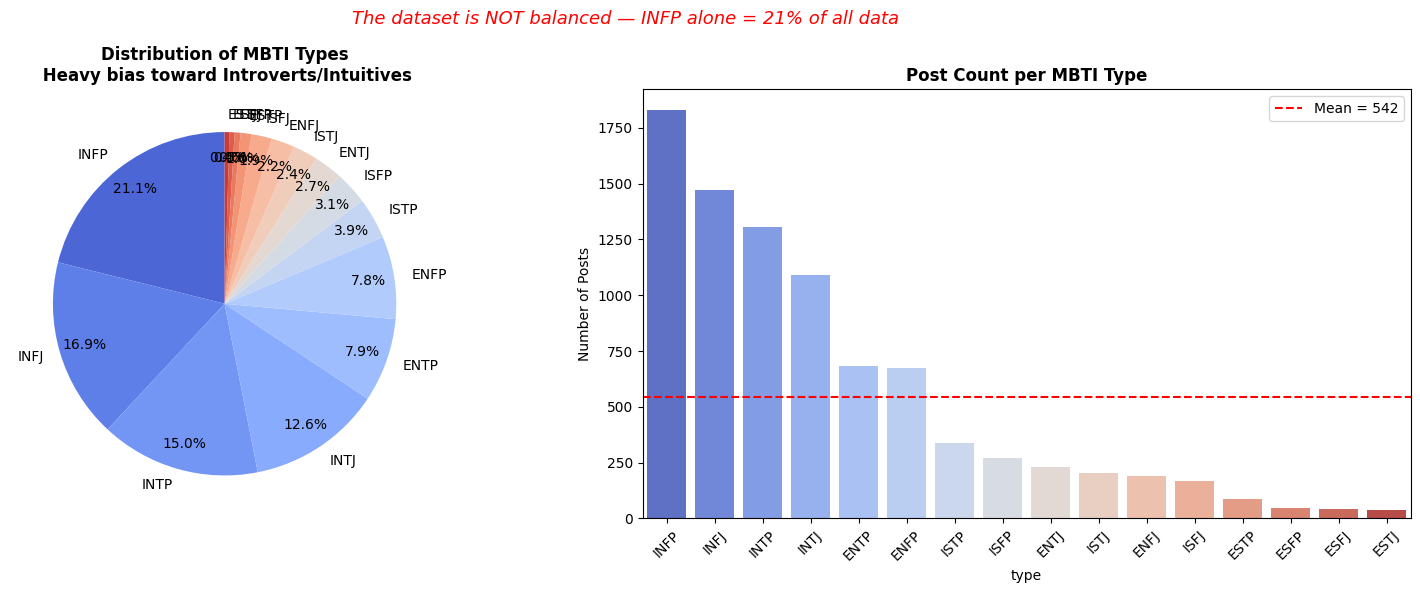

In [97]:
# Q1: Is the data balanced? Imbalanced data = biased conclusions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts = df['type'].value_counts()
colors = sns.color_palette('coolwarm', 16)

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.85)
axes[0].set_title('Distribution of MBTI Types\n Heavy bias toward Introverts/Intuitives',
                  fontweight='bold')

sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[1])
axes[1].axhline(counts.mean(), color='red', linestyle='--',
                label=f'Mean = {counts.mean():.0f}')
axes[1].set_title('Post Count per MBTI Type', fontweight='bold')
axes[1].set_ylabel('Number of Posts')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('The dataset is NOT balanced — INFP alone = 21% of all data',
             fontsize=13, color='red', fontstyle='italic')
plt.tight_layout()
plt.show()




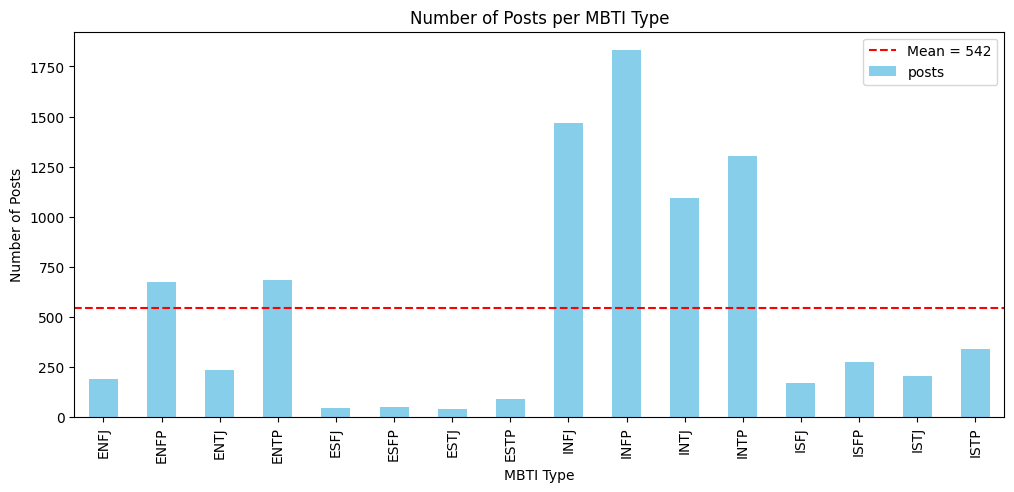

In [96]:
# Q2: Does post count differ across types — and does that affect our analysis?
post_counts = df.groupby('type')['posts'].count()
post_counts.plot(kind='bar', figsize=(12,5), color='skyblue')
plt.axhline(post_counts.mean(), color='red', linestyle='--', label=f'Mean = {post_counts.mean():.0f}')
plt.title("Number of Posts per MBTI Type")
plt.ylabel("Number of Posts")
plt.xlabel("MBTI Type")
plt.legend()
plt.show()

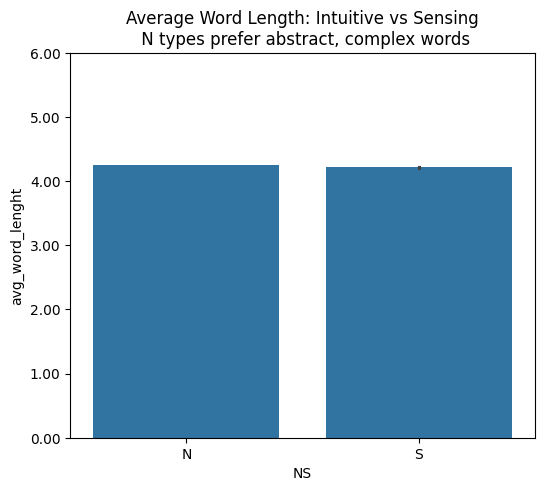

In [94]:
# Q3: Do Intuitive types use more complex vocabulary than Sensing types?
#what is intuitive and what is sensing
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='NS', y='avg_word_lenght')
plt.title("Average Word Length: Intuitive vs Sensing\n N types prefer abstract, complex words")
plt.ylim(0,6)
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

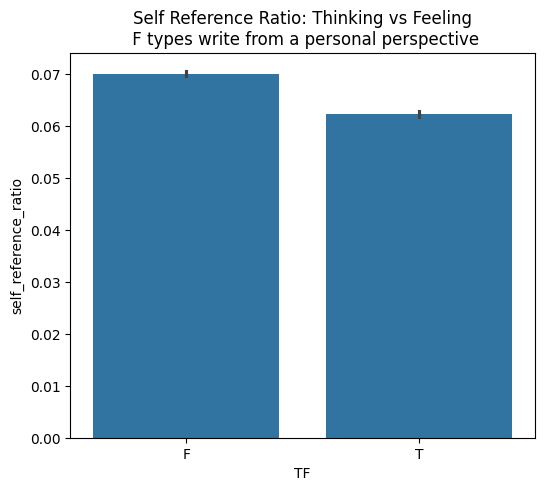

In [95]:
# Q4: Do Feeling types talk about themselves more than Thinking types?
#feelings and thinking?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='self_reference_ratio')
plt.title("Self Reference Ratio: Thinking vs Feeling\n F types write from a personal perspective")
plt.show()

/tmp/ipykernel_798/4101233007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='Word_count', data=avg_word_count, palette='Blues_d')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


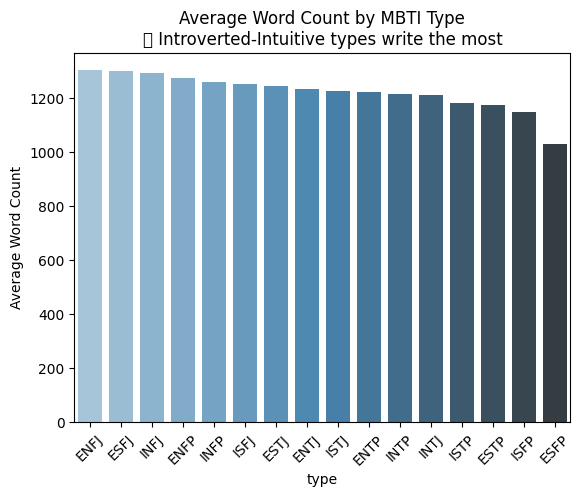

In [15]:
# Q6: Do certain MBTI types write longer posts on average?
avg_word_count = df.groupby('type')['Word_count'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='type', y='Word_count', data=avg_word_count, palette='Blues_d')
plt.title("Average Word Count by MBTI Type\n Introverted-Intuitive types write the most")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.show()

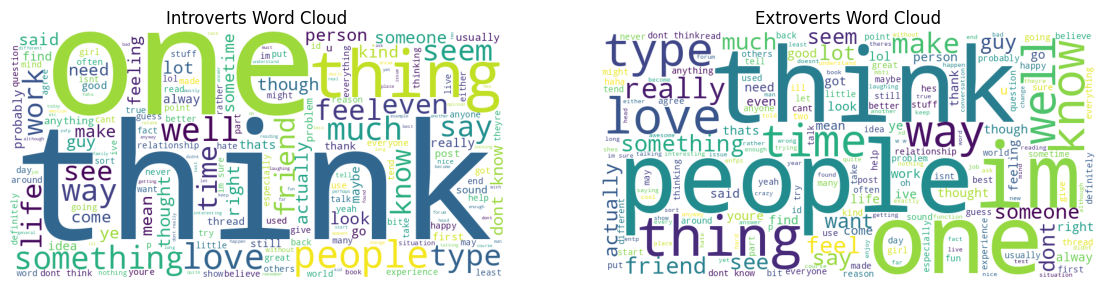

In [16]:
# Q5: What words define Introverts vs Extroverts?
intro_text = " ".join(df[df['IE'] == 'I']['clean_posts']).split()
intro_words = [w for w in intro_text if w not in stop_words]
extro_text = " ".join(df[df['IE'] == 'E']['clean_posts']).split()
extro_words = [w for w in extro_text if w not in stop_words]

wc_intro = WordCloud(width=800, height=400, background_color='white').generate(" ".join(intro_words))
wc_extro = WordCloud(width=800, height=400, background_color='white').generate(" ".join(extro_words))

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_intro)
plt.axis("off")
plt.title("Introverts Word Cloud")
plt.subplot(1,2,2)
plt.imshow(wc_extro)
plt.axis("off")
plt.title("Extroverts Word Cloud")
plt.show()

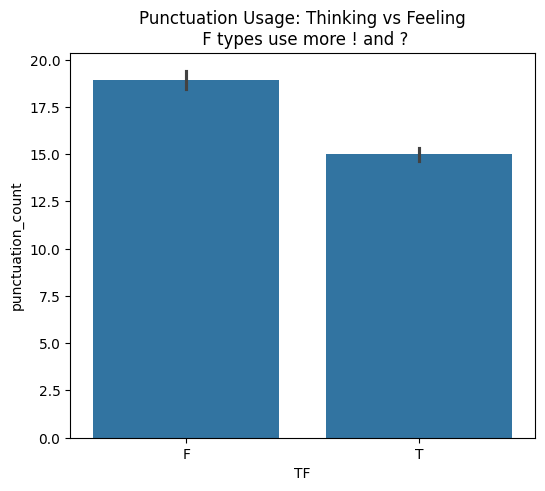

In [92]:
# Q7: Does punctuation usage reveal emotional expressiveness?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='punctuation_count')
plt.title("Punctuation Usage: Thinking vs Feeling\n F types use more ! and ?")
plt.show()

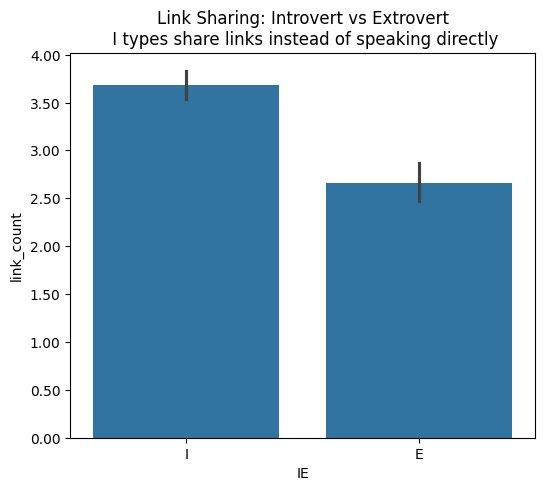

In [93]:
# Q8: Do Introverts share more links than Extroverts?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='IE', y='link_count')
plt.title("Link Sharing: Introvert vs Extrovert\n I types share links instead of speaking directly")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

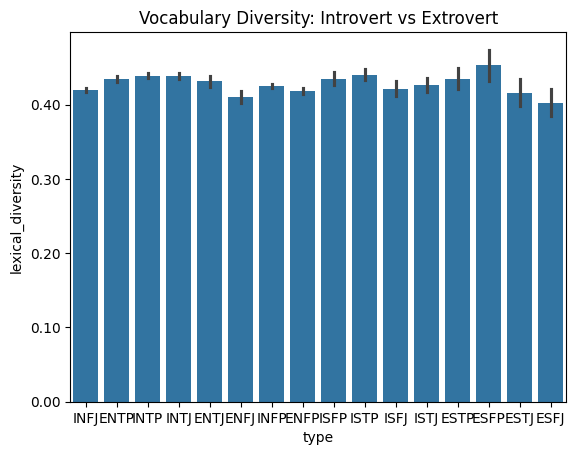

In [19]:
# Q9: Do certain types write with more vocabulary diversity?
sns.barplot(data=df, x='type', y='lexical_diversity')
plt.title("Vocabulary Diversity: Introvert vs Extrovert")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

/tmp/ipykernel_798/2936592958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TF', y='sentiment', palette='Set1', ax=axes[1])


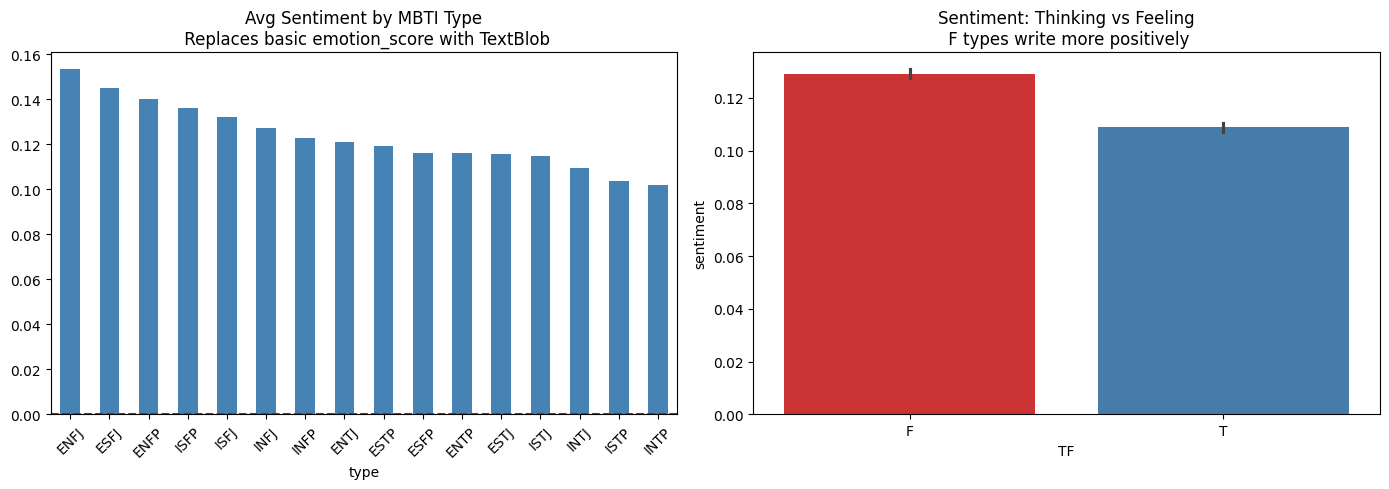

In [91]:
# Q10: Which MBTI types write most positively or negatively?
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sentiment_avg = df.groupby('type')['sentiment'].mean().sort_values(ascending=False)
sentiment_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Avg Sentiment by MBTI Type\n Replaces basic emotion_score with TextBlob")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='TF', y='sentiment', palette='Set1', ax=axes[1])
axes[1].set_title("Sentiment: Thinking vs Feeling\n F types write more positively")

plt.tight_layout()
plt.show()

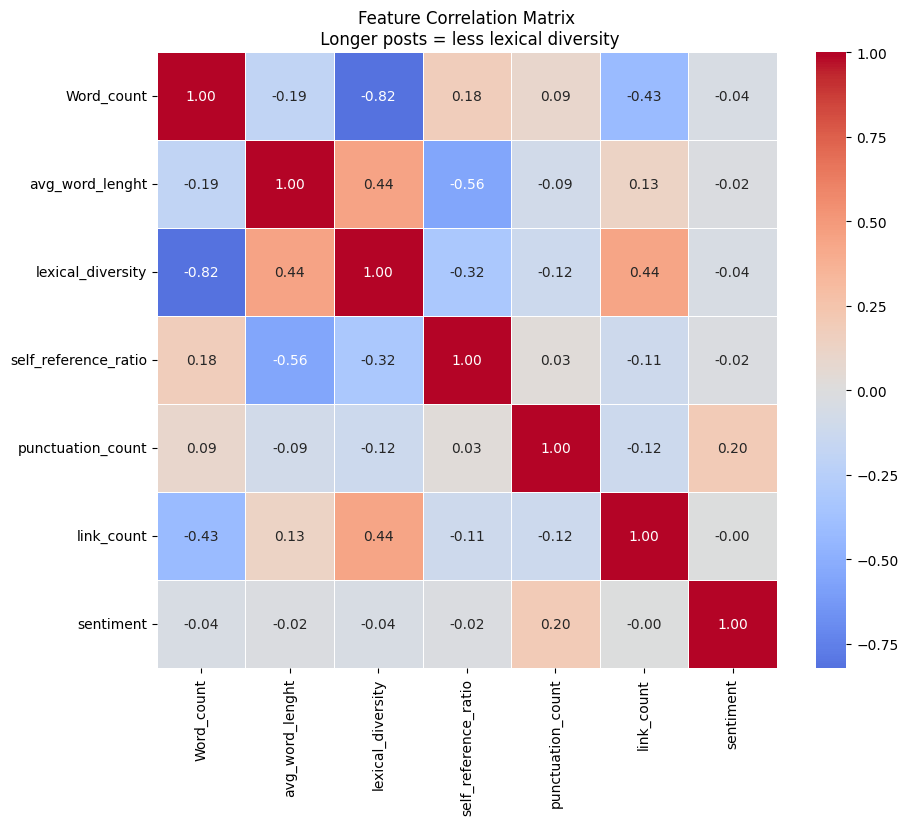

In [90]:
# Q11: Which features are correlated with each other?
plt.figure(figsize=(10,8))
sns.heatmap(df[['Word_count','avg_word_lenght','lexical_diversity','self_reference_ratio',
                'punctuation_count','link_count','sentiment']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix\n Longer posts = less lexical diversity")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


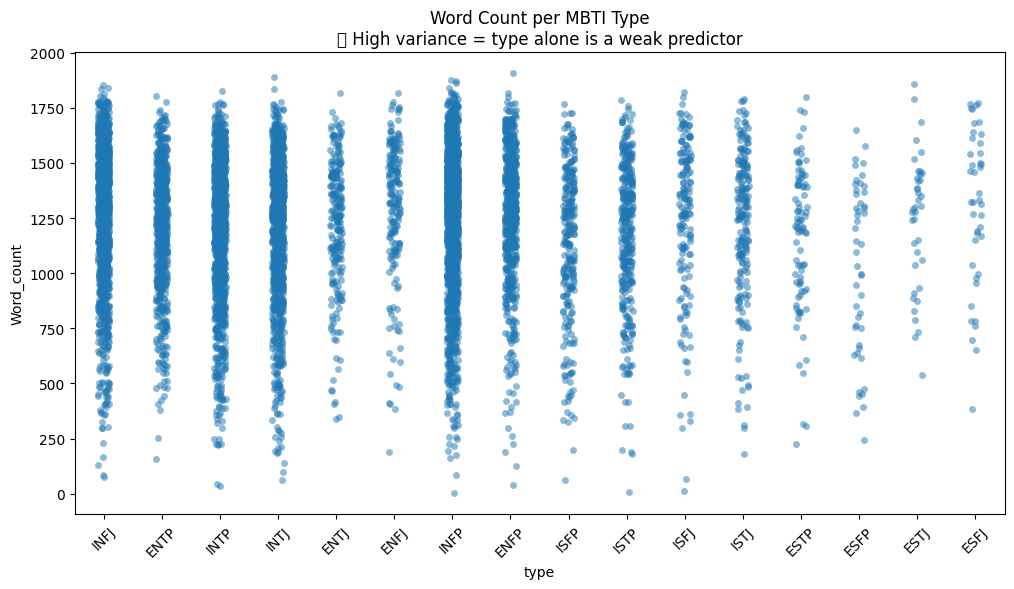

In [23]:
# Q12: Is there high variance in writing length within each type?
plt.figure(figsize=(12,6))
sns.stripplot(data=df, x='type', y='Word_count', jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.title("Word Count per MBTI Type\n💡 High variance = type alone is a weak predictor")
plt.show()

/tmp/ipykernel_798/1631959299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='JP', y='punctuation_count', palette=['lightblue','salmon'])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


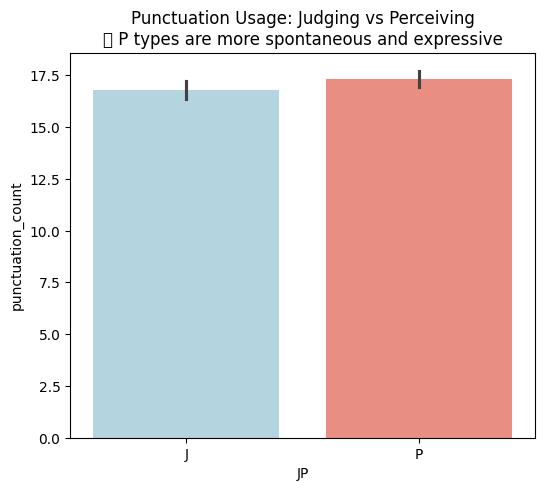

In [24]:
# Q15: Do Judging types use more punctuation than Perceiving types?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='JP', y='punctuation_count', palette=['lightblue','salmon'])
plt.title("Punctuation Usage: Judging vs Perceiving\n💡 P types are more spontaneous and expressive")
plt.show()

/tmp/ipykernel_798/3211663344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TF', y='link_count', palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


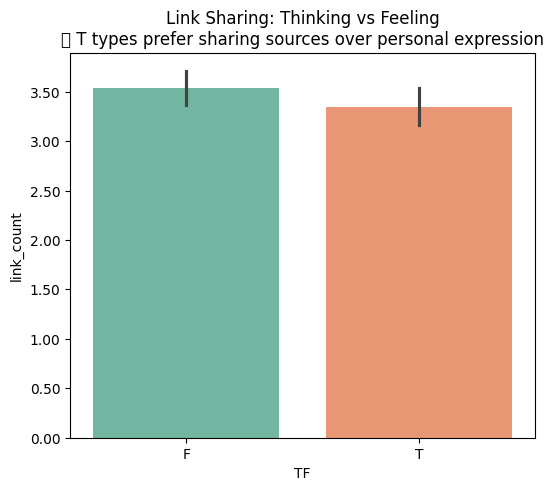

In [25]:
# Q16: Do Thinking types share more links than Feeling types?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='link_count', palette='Set2')
plt.title("Link Sharing: Thinking vs Feeling\n💡 T types prefer sharing sources over personal expression")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

/tmp/ipykernel_798/3429040527.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JP', y='Word_count', palette='Set2', ax=axes[0])
/tmp/ipykernel_798/3429040527.py:14: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


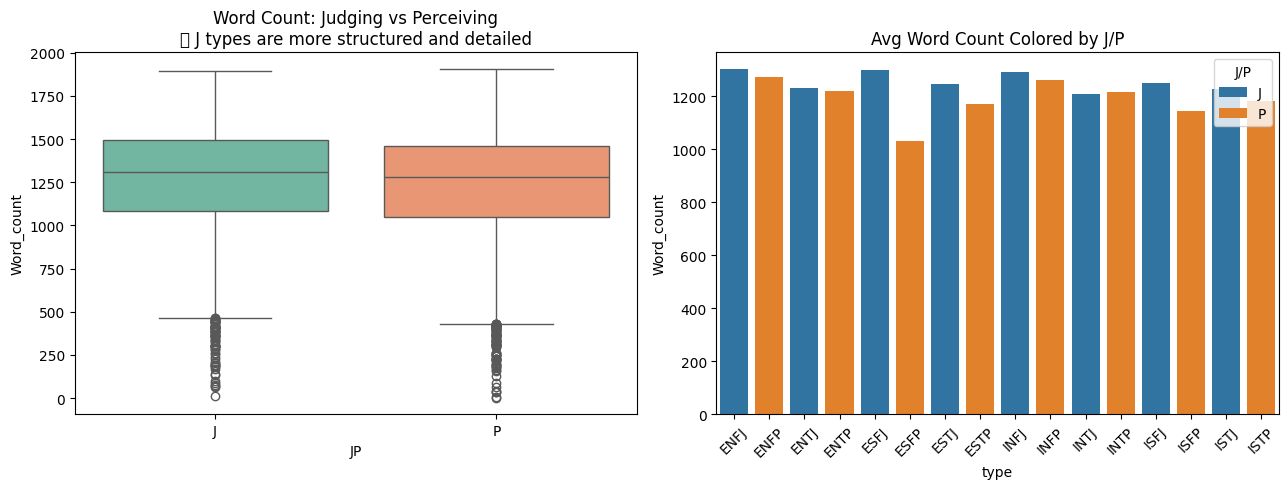

In [26]:
# Q18: Do Judging types write longer posts than Perceiving types?
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=df, x='JP', y='Word_count', palette='Set2', ax=axes[0])
axes[0].set_title("Word Count: Judging vs Perceiving\n💡 J types are more structured and detailed")

avg_jp = df.groupby('type')['Word_count'].mean().reset_index()
avg_jp['JP'] = avg_jp['type'].apply(lambda x: x[3])
sns.barplot(data=avg_jp, x='type', y='Word_count', hue='JP', ax=axes[1], dodge=False)
axes[1].set_title("Avg Word Count Colored by J/P")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='J/P')

plt.tight_layout()
plt.show()

--- IE ---
              precision    recall  f1-score   support

           E       0.49      0.60      0.54       400
           I       0.87      0.81      0.84      1335

    accuracy                           0.76      1735
   macro avg       0.68      0.71      0.69      1735
weighted avg       0.78      0.76      0.77      1735

--- NS ---
              precision    recall  f1-score   support

           N       0.92      0.85      0.88      1496
           S       0.36      0.52      0.43       239

    accuracy                           0.81      1735
   macro avg       0.64      0.69      0.66      1735
weighted avg       0.84      0.81      0.82      1735

--- TF ---
              precision    recall  f1-score   support

           F       0.83      0.82      0.83       939
           T       0.79      0.81      0.80       796

    accuracy                           0.81      1735
   macro avg       0.81      0.81      0.81      1735
weighted avg       0.81      0.81      0.

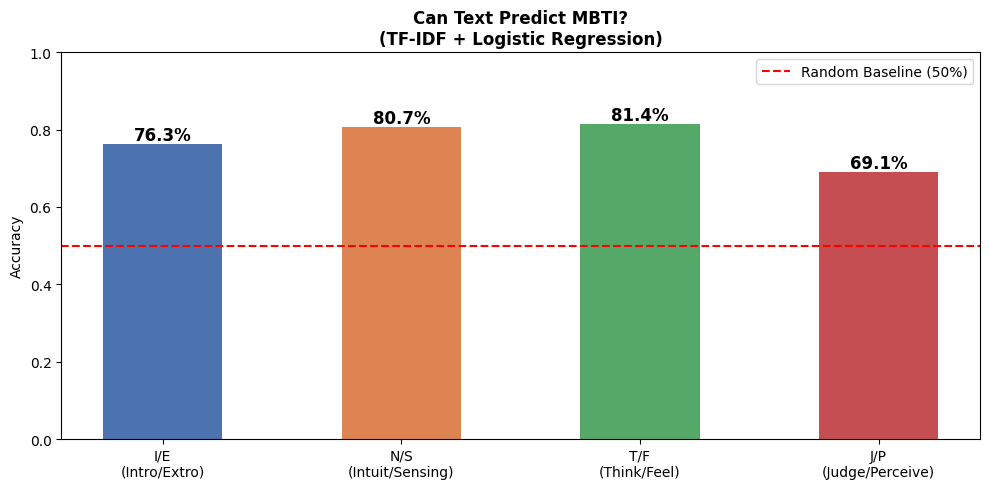

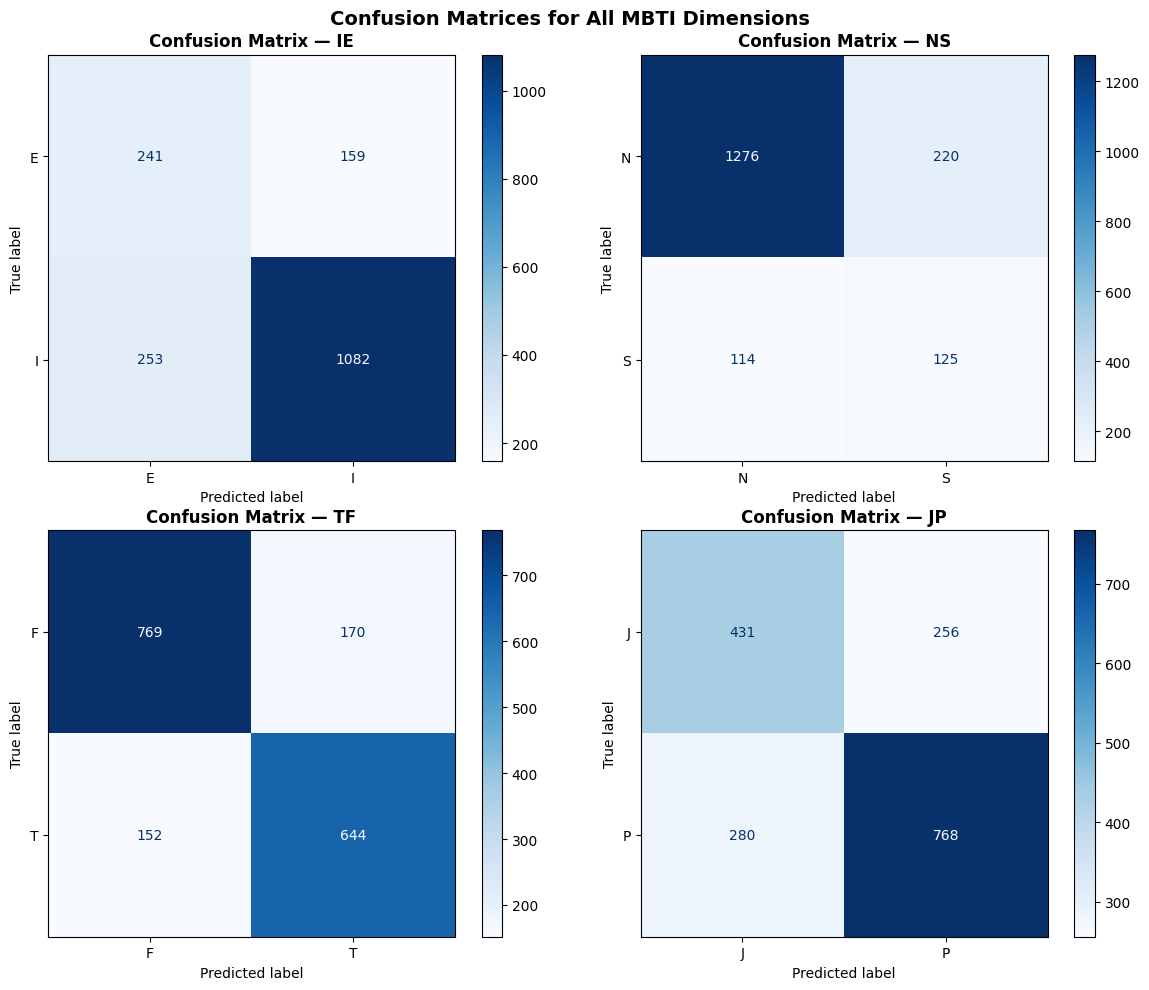

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import random

results = {}
models = {}
tfidfs = {}
y_tests = {}
y_preds = {}
X_tests_raw = {}

for dim in ['IE', 'NS', 'TF', 'JP']:
    X = df['clean_posts']
    y = df[dim]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    X_tests_raw[dim] = X_test

    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
    X_train = tfidf.fit_transform(X_train)
    X_test  = tfidf.transform(X_test)

    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    results[dim] = accuracy_score(y_test, y_pred)
    models[dim]  = clf
    tfidfs[dim]  = tfidf
    y_tests[dim] = y_test
    y_preds[dim] = y_pred

    print(f'--- {dim} ---')
    print(classification_report(y_test, y_pred))

# Accuracy Bar Chart
labels = ['I/E\n(Intro/Extro)', 'N/S\n(Intuit/Sensing)',
          'T/F\n(Think/Feel)',  'J/P\n(Judge/Perceive)']
accs = [results[d] for d in ['IE','NS','TF','JP']]

plt.figure(figsize=(10,5))
bars = plt.bar(labels, accs, color=['#4C72B0','#DD8452','#55A868','#C44E52'], width=0.5)
plt.axhline(0.5, color='red', linestyle='--', label='Random Baseline (50%)')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Can Text Predict MBTI?\n(TF-IDF + Logistic Regression)', fontweight='bold')
plt.legend()
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, dim in zip(axes.flat, ['IE','NS','TF','JP']):
    cm = confusion_matrix(y_tests[dim], y_preds[dim])
    ConfusionMatrixDisplay(cm, display_labels=models[dim].classes_).plot(cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {dim}', fontweight='bold')

plt.suptitle('Confusion Matrices for All MBTI Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Predict Function with Confidence
def predict_mbti(text):
    text = re.sub(r'\s+', ' ', re.sub(r'[^a-z\s!?]', '', re.sub(
        r'\b(infj|entp|intp|intj|entj|infp|enfp|istp|isfp|estj|istj|enfj|isfj|esfj|esfp|estp)\b', '',
        re.sub(r'\|\|\|', ' ', re.sub(r'http\S+|www\S+', '', text.lower()))))).strip()
    mbti = ''
    confidence = {}
    for dim in ['IE', 'NS', 'TF', 'JP']:
        x     = tfidfs[dim].transform([text])
        pred  = models[dim].predict(x)[0]
        proba = models[dim].predict_proba(x)[0].max()
        mbti += pred
        confidence[dim] = (pred, proba)
    return mbti, confidence



In [89]:
# Random Sample Prediction
idx = random.randint(0, len(X_tests_raw['IE']) - 1)
sample_text  = X_tests_raw['IE'].iloc[idx]
actual_type  = df.loc[X_tests_raw['IE'].index[idx], 'type']
mbti, confidence = predict_mbti(sample_text)

print(f'Sample Text:\n{sample_text[:300]}...')
print(f'\nActual MBTI   : {actual_type}')
print(f'Predicted MBTI: {mbti}')
print('-' * 30)
for dim, (pred, prob) in confidence.items():
    actual_dim = actual_type[['IE','NS','TF','JP'].index(dim)]
    status = 'True' if pred == actual_dim else 'False'
    print(f'{dim}: {pred} — {prob*100:.1f}% {status}')

Sample Text:
hahaha i love that song what would be the point of him going into the wild if he already knew how to do everything? he wanted to explore he made his own maps he didnt have every single piece of gear that would make his the amount of energy in this is ridiculous this is the song that heralds the apoc...

Actual MBTI   : INFP
Predicted MBTI: ISFP
------------------------------
IE: I — 79.5% True
NS: S — 59.5% False
TF: F — 79.0% True
JP: P — 57.2% True
